# a)
Dla podanej funkcji kwadratowej:
$$f(x,y) = \frac{1}{2}x^2 + \frac{9}{2}y^2$$

Możemy wyznaczyć analitycznie optymalną wartość kroku $\alpha_k$, opierając się na macierzy Hessego (drugich pochodnych).

Gradient funkcji to: $\nabla f(x,y) = \begin{bmatrix} x \\ 9y \end{bmatrix}$

Macierz Hessego to: $H = \begin{bmatrix} 1 & 0 \\ 0 & 9 \end{bmatrix}$

Wzór na optymalny krok to:
$$\alpha_k = \frac{\nabla f(\mathbf{x}_k)^T \nabla f(\mathbf{x}_k)}{\nabla f(\mathbf{x}_k)^T H \nabla f(\mathbf{x}_k)}$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x, y):
    return 0.5 * x**2 + 4.5 * y**2

def gradient(x, y):
    return np.array([x, 9.0 * y])

In [4]:
H = np.array([[1.0, 0.0], [0.0, 9.0]])

x_k = np.array([9.0, 1.0])
tolerance = 1e-6
max_iter = 100

In [5]:
path = [x_k.copy()]

for i in range(max_iter):
    grad = gradient(x_k[0], x_k[1])

    if np.linalg.norm(grad) < tolerance:
        print(f"Minimum znalezione w iteracji {i}.")
        break

    # (grad^T * grad) / (grad^T * H * grad)
    alpha_k = np.dot(grad, grad) / np.dot(grad, np.dot(H, grad))

    x_k = x_k - alpha_k * grad
    path.append(x_k.copy())

path = np.array(path)

Minimum znalezione w iteracji 74.


In [6]:
print(f"Znalezione minimum w punkcie: x = {x_k[0]:.6f}, y = {x_k[1]:.6f}")
print(f"Wartość funkcji w minimum: {f(x_k[0], x_k[1]):.6f}")

Znalezione minimum w punkcie: x = 0.000001, y = 0.000000
Wartość funkcji w minimum: 0.000000


In [7]:
x_range = np.linspace(-2, 10, 400)
y_range = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

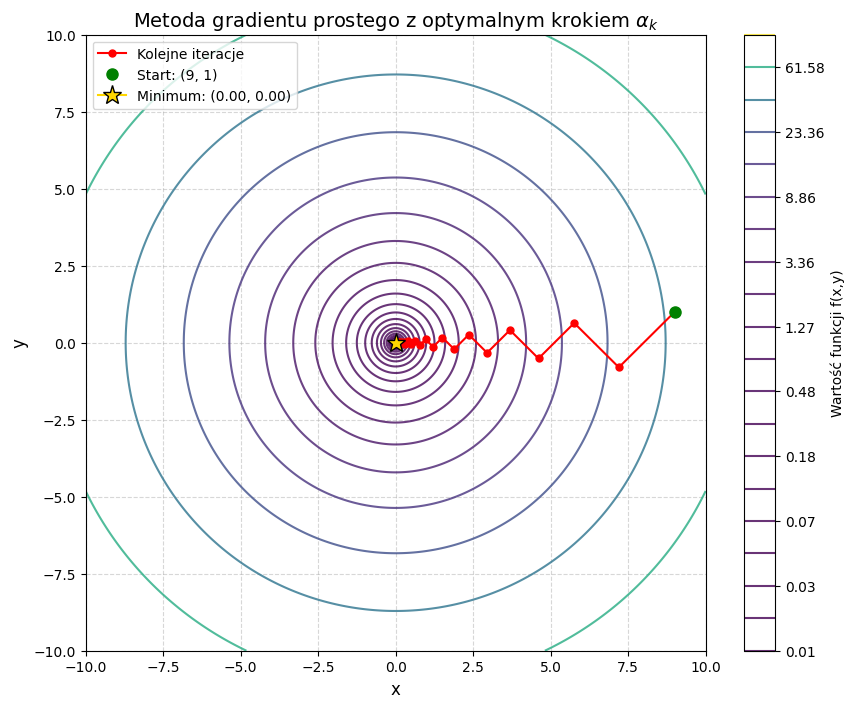

In [16]:
plt.figure(figsize=(10, 8))

levels = np.logspace(-2, 2, 20)
cp = plt.contour(X, Y, Z, levels=levels, cmap="viridis", alpha=0.8)
plt.colorbar(cp, label="Wartość funkcji f(x,y)")

plt.plot(
    path[:, 0], path[:, 1], "ro-", label="Kolejne iteracje", markersize=5, linewidth=1.5
)

plt.plot(path[0, 0], path[0, 1], "go", label="Start: (9, 1)", markersize=8)
plt.plot(
    path[-1, 0],
    path[-1, 1],
    marker='*',
    color='gold',
    markersize=14,
    markeredgecolor='black',
    label=f"Minimum: ({path[-1][0]:.2f}, {path[-1][1]:.2f})",
)

plt.title("Metoda gradientu prostego z optymalnym krokiem $\\alpha_k$", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


# b)
Aby obliczyć współczynnik uwarunkowania, musimy najpierw wyznaczyć macierz drugich pochodnych (macierz Hessego, inaczej hesjan), czyli $\nabla^2 f(x,y)$.

Dla funkcji $f(x,y) = \frac{1}{2}x^2 + \frac{9}{2}y^2$ pierwsze pochodne to:
$$\frac{\partial f}{\partial x} = x$$
$$\frac{\partial f}{\partial y} = 9y$$

Drugie pochodne tworzą macierz Hessego $H$:
$$\nabla^2 f(x,y) = H = \begin{bmatrix} 1 & 0 \\ 0 & 9 \end{bmatrix}$$

Macierz ta jest symetryczna i dodatnio określona. Współczynnik uwarunkowania takiej macierzy to stosunek jej największej do najmniejszej wartości własnej:
$$\kappa(H) = \frac{\lambda_{max}}{\lambda_{min}}$$
Ponieważ nasza macierz $H$ jest diagonalna, jej wartości własne znajdują się bezpośrednio na głównej przekątnej. Są to $\lambda_1 = 1$ oraz $\lambda_2 = 9$.

Obliczamy współczynnik uwarunkowania:
$$\kappa(H) = \frac{9}{1} = 9$$

# c)
Szukamy macierzy dolnotrójkątnej $L$ takiej, że $H = LL^T$.

Macierz $H$ zdefiniowana jest jako:
$$H = \begin{bmatrix} 1 & 0 \\ 0 & 9 \end{bmatrix}$$
Dla macierzy diagonalnej o dodatnich elementach na przekątnej, znalezienie macierzy $L$ jest bardzo proste. Macierz $L$ będzie również diagonalna (co spełnia warunek bycia dolnotrójkątną), a jej elementy to pierwiastki kwadratowe z elementów na przekątnej macierzy $H$.

Obliczamy macierz $L$:
$$L = \begin{bmatrix} \sqrt{1} & 0 \\ 0 & \sqrt{9} \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 3 \end{bmatrix}$$
Możemy to łatwo sprawdzić, wymnażając macierze $LL^T$:
$$LL^T = \begin{bmatrix} 1 & 0 \\ 0 & 3 \end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & 3 \end{bmatrix} = \begin{bmatrix} 1\cdot 1 + 0\cdot 0 & 1\cdot 0 + 0\cdot 3 \\ 0\cdot 1 + 3\cdot 0 & 0\cdot 0 + 3\cdot 3 \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 9 \end{bmatrix} = \nabla^2 f(x,y)$$

# d)
## Krok 1: Wyznaczenie odwrotności transponowanej macierzy $L$
Macierz $L$, którą wyznaczyliśmy w podpunkcie (c), to:
$$L = \begin{bmatrix} 1 & 0 \\ 0 & 3 \end{bmatrix}$$
Ponieważ $L$ jest macierzą diagonalną, jej transpozycja jest równa jej samej, czyli $L^T = L$.
Aby znaleźć macierz $L^{-T}$ (odwrotność macierzy transponowanej), wystarczy odwrócić elementy na przekątnej macierzy $L$:
$$L^{-T} = (L^T)^{-1} = L^{-1} = \begin{bmatrix} 1 & 0 \\ 0 & \frac{1}{3} \end{bmatrix}$$

## Krok 2: Zdefiniowanie nowej funkcji $g(x', y')$
Zgodnie ze wzorem (3), podstawienie zmiennych wygląda następująco:
$$\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & \frac{1}{3} \end{bmatrix} \begin{bmatrix} x' \\ y' \end{bmatrix} = \begin{bmatrix} x' \\ \frac{1}{3}y' \end{bmatrix}$$
Oznacza to, że $x = x'$ oraz $y = \frac{1}{3}y'$.
Podstawiając to do oryginalnej funkcji $f(x,y) = \frac{1}{2}x^2 + \frac{9}{2}y^2$, otrzymujemy wzór na funkcję $g(x',y')$:
$$g(x', y') = \frac{1}{2}(x')^2 + \frac{9}{2}\left(\frac{1}{3}y'\right)^2$$
$$g(x', y') = \frac{1}{2}(x')^2 + \frac{9}{2}\left(\frac{1}{9}(y')^2\right)$$
$$g(x', y') = \frac{1}{2}(x')^2 + \frac{1}{2}(y')^2$$

## Krok 3: Minimum funkcji $g$ metodą gradientu prostego
Przeanalizujmy nową funkcję $g(x', y')$. Jej wektor gradientu to:
$$\nabla g(x', y') = \begin{bmatrix} x' \\ y' \end{bmatrix}$$
Macierz Hessego dla zoptymalizowanej funkcji $g$ przyjmuje postać macierzy jednostkowej:$$\nabla^2 g(x', y') = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = I$$Współczynnik uwarunkowania tej macierzy wynosi $1$ (ponieważ $\kappa = \frac{1}{1}$). Jest to kluczowy cel preconditioningu – wyrównaliśmy kształt poziomic funkcji z wydłużonych elips do idealnych okręgów.
Zastosujmy krok metody gradientu prostego. Optymalny krok $\alpha_k$ dla nowej funkcji kwadratowej wynosi:
$$\alpha_k = \frac{\nabla g^T \nabla g}{\nabla g^T I \nabla g} = \frac{\|\nabla g\|^2}{\|\nabla g\|^2} = 1$$
Aktualizacja pozycji w pierwszej iteracji (niezależnie od wybranego punktu startowego):
$$\begin{bmatrix} x'_{k+1} \\ y'_{k+1} \end{bmatrix} = \begin{bmatrix} x'_k \\ y'_k \end{bmatrix} - 1 \cdot \begin{bmatrix} x'_k \\ y'_k \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$
Dzięki zmianie układu współrzędnych algorytm gradientu prostego z optymalnym krokiem dociera do minimum funkcji $g(x', y')$ w dokładnie jednej iteracji, a to minimum znajduje się w punkcie $(x', y') = (0, 0)$.

## Krok 4: Wyznaczenie minimum funkcji $f$ na podstawie wzoru (3)
Znamy już współrzędne minimum funkcji $g$, czyli $[x', y']^T = [0, 0]^T$.
Aby wrócić do oryginalnego układu i znaleźć minimum bazowej funkcji $f(x,y)$, korzystamy ponownie z zależności (3):
$$\begin{bmatrix} x \\ y \end{bmatrix} = L^{-T} \begin{bmatrix} x' \\ y' \end{bmatrix}$$
Po podstawieniu wyliczonych wektorów:
$$\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & \frac{1}{3} \end{bmatrix} \begin{bmatrix} 0 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix}$$

In [9]:
L = np.array([[1.0, 0.0], [0.0, 3.0]])

L_inv_T = np.array([[1.0, 0.0], [0.0, 1 / 3]])

In [10]:
def g(x_prime, y_prime):
    return 0.5 * x_prime**2 + 0.5 * y_prime**2

def gradient_g(x_prime, y_prime):
    return np.array([x_prime, y_prime])

In [11]:
x0_original = np.array([9.0, 1.0])

x_k_prime = L.dot(x0_original)
print(f"Punkt startowy w nowym układzie (x', y'): {x_k_prime}")

tolerance = 1e-6
max_iter = 100
path_prime = [x_k_prime.copy()]

identity_matrix = np.array([[1.0, 0.0], [0.0, 1.0]])

Punkt startowy w nowym układzie (x', y'): [9. 3.]


In [12]:
for i in range(max_iter):
    grad = gradient_g(x_k_prime[0], x_k_prime[1])

    if np.linalg.norm(grad) < tolerance:
        print(f"Minimum znalezione w iteracji {i} (w nowym układzie).")
        break

    alpha_k = np.dot(grad, grad) / np.dot(grad, np.dot(identity_matrix, grad))

    x_k_prime = x_k_prime - alpha_k * grad
    path_prime.append(x_k_prime.copy())

path_prime = np.array(path_prime)

x_min_original = L_inv_T.dot(x_k_prime)

Minimum znalezione w iteracji 1 (w nowym układzie).


In [13]:
print(f"Znalezione minimum g(x', y'): x' = {x_k_prime[0]:.6f}, y' = {x_k_prime[1]:.6f}")
print(
    f"Minimum po powrocie do f(x, y): x = {x_min_original[0]:.6f}, y = {x_min_original[1]:.6f}"
)

Znalezione minimum g(x', y'): x' = 0.000000, y' = 0.000000
Minimum po powrocie do f(x, y): x = 0.000000, y = 0.000000


In [14]:
x_range = np.linspace(-10, 10, 400)
y_range = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = g(X, Y)

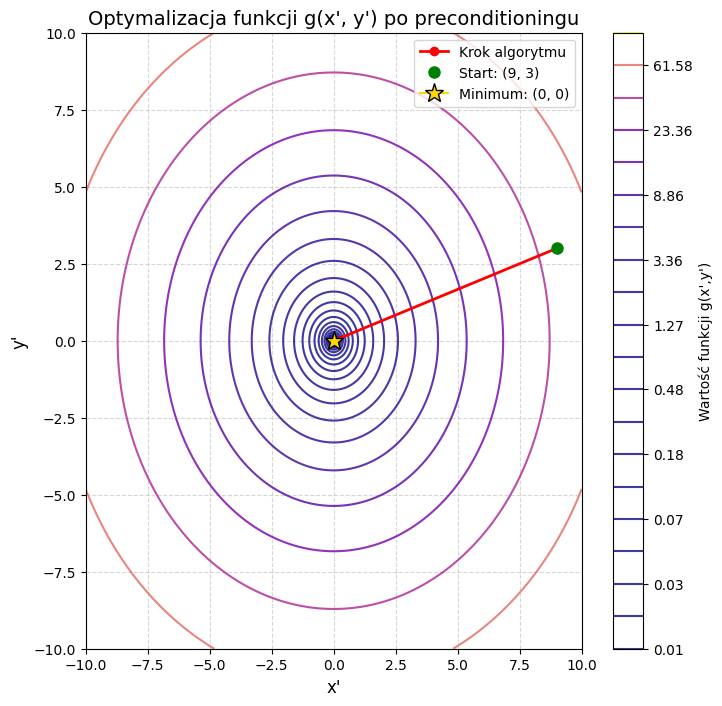

In [15]:
plt.figure(figsize=(8, 8))

levels = np.logspace(-2, 2, 20)
cp = plt.contour(X, Y, Z, levels=levels, cmap="plasma", alpha=0.8)
plt.colorbar(cp, label="Wartość funkcji g(x',y')")

plt.plot(
    path_prime[:, 0],
    path_prime[:, 1],
    "ro-",
    label="Krok algorytmu",
    markersize=6,
    linewidth=2,
)
plt.plot(
    path_prime[0, 0],
    path_prime[0, 1],
    "go",
    label=f"Start: ({path_prime[0, 0]:.0f}, {path_prime[0, 1]:.0f})",
    markersize=8,
)
plt.plot(
    path_prime[-1, 0],
    path_prime[-1, 1],
    marker='*',
    color='gold',
    markersize=14,
    markeredgecolor='black',
    label=f"Minimum: ({path_prime[-1, 0]:.0f}, {path_prime[-1, 1]:.0f})",
)

plt.title("Optymalizacja funkcji g(x', y') po preconditioningu", fontsize=14)
plt.xlabel("x'", fontsize=12)
plt.ylabel("y'", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()